In [29]:
import random
import numpy
import pandas
import joblib
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from typing import Any

In [30]:
# Define random seeds for reproducibility
SEED: int = 42
random.seed(SEED)
numpy.random.seed(SEED)

In [31]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [32]:
def load_model_package(filepath: str) -> dict[str, Any]:
    return joblib.load(filepath)

In [33]:
def apply_proportional_noise(
        X_test: pandas.DataFrame,
        train_std: pandas.Series,
        noise_fraction: float,
        continuous_cols: list[str]) -> pandas.DataFrame:
    """
    Adds Gaussian noise to the test data, but ONLY to the specified continuous variables,
    proportional to the standard deviation of the training data.
    noise_fraction: from 0.0 to 1.0 (0% - 100%)
    """
    if numpy.isclose(noise_fraction, 0.0, rtol=1e-09, atol=1e-09):
        return X_test.copy()

    # Create a copy of the test data to avoid modifying the original
    X_test_noisy: pandas.DataFrame = X_test.copy()

    # Iterate only over the continuous columns
    for col in continuous_cols:
        # Safety check: is the column in the test data and in the std series?
        if col in X_test_noisy.columns and col in train_std.index:
            # Generate noise specifically for this column
            noise: numpy.ndarray = numpy.random.normal(
                loc=0.0,
                scale=noise_fraction * train_std[col],
                size=len(X_test_noisy)
            )
            # Add the noise to the column
            X_test_noisy[col] += noise

    return X_test_noisy

In [34]:
def evaluate_pipeline(model_pkg: dict[str, Any], X_noisy: pandas.DataFrame, y_true: pandas.Series) -> float:
    """
    Selects the features, scales, predicts, and returns the ROC-AUC.
    """
    model: LogisticRegression = model_pkg["model"]
    scaler: StandardScaler = model_pkg["scaler"]
    features: list[str] = model_pkg["features"]

    # Select only the features relevant to the model
    X_subset: pandas.DataFrame = X_noisy[features]

    # Scale using the pre-saved scaler
    X_scaled: numpy.ndarray = scaler.transform(X_subset.to_numpy())

    # Predict probabilities (predict_proba for ROC-AUC)
    y_pred_proba: numpy.ndarray = model.predict_proba(X_scaled)[:, 1] # Positive class probability

    # Calculate ROC-AUC
    return roc_auc_score(y_true, y_pred_proba)

Evaluation started for different noise levels...
    - Noise:   0% | Multi AUC: 0.4813 | Single AUC: 0.5155
    - Noise:  10% | Multi AUC: 0.4814 | Single AUC: 0.5157
    - Noise:  20% | Multi AUC: 0.4793 | Single AUC: 0.5164
    - Noise:  30% | Multi AUC: 0.4807 | Single AUC: 0.5156
    - Noise:  40% | Multi AUC: 0.4840 | Single AUC: 0.5145
    - Noise:  50% | Multi AUC: 0.4818 | Single AUC: 0.5183
    - Noise:  60% | Multi AUC: 0.4819 | Single AUC: 0.5155
    - Noise:  70% | Multi AUC: 0.4858 | Single AUC: 0.5104
    - Noise:  80% | Multi AUC: 0.4877 | Single AUC: 0.5107
    - Noise:  90% | Multi AUC: 0.4807 | Single AUC: 0.5144
    - Noise: 100% | Multi AUC: 0.4899 | Single AUC: 0.5057
Plot generation...


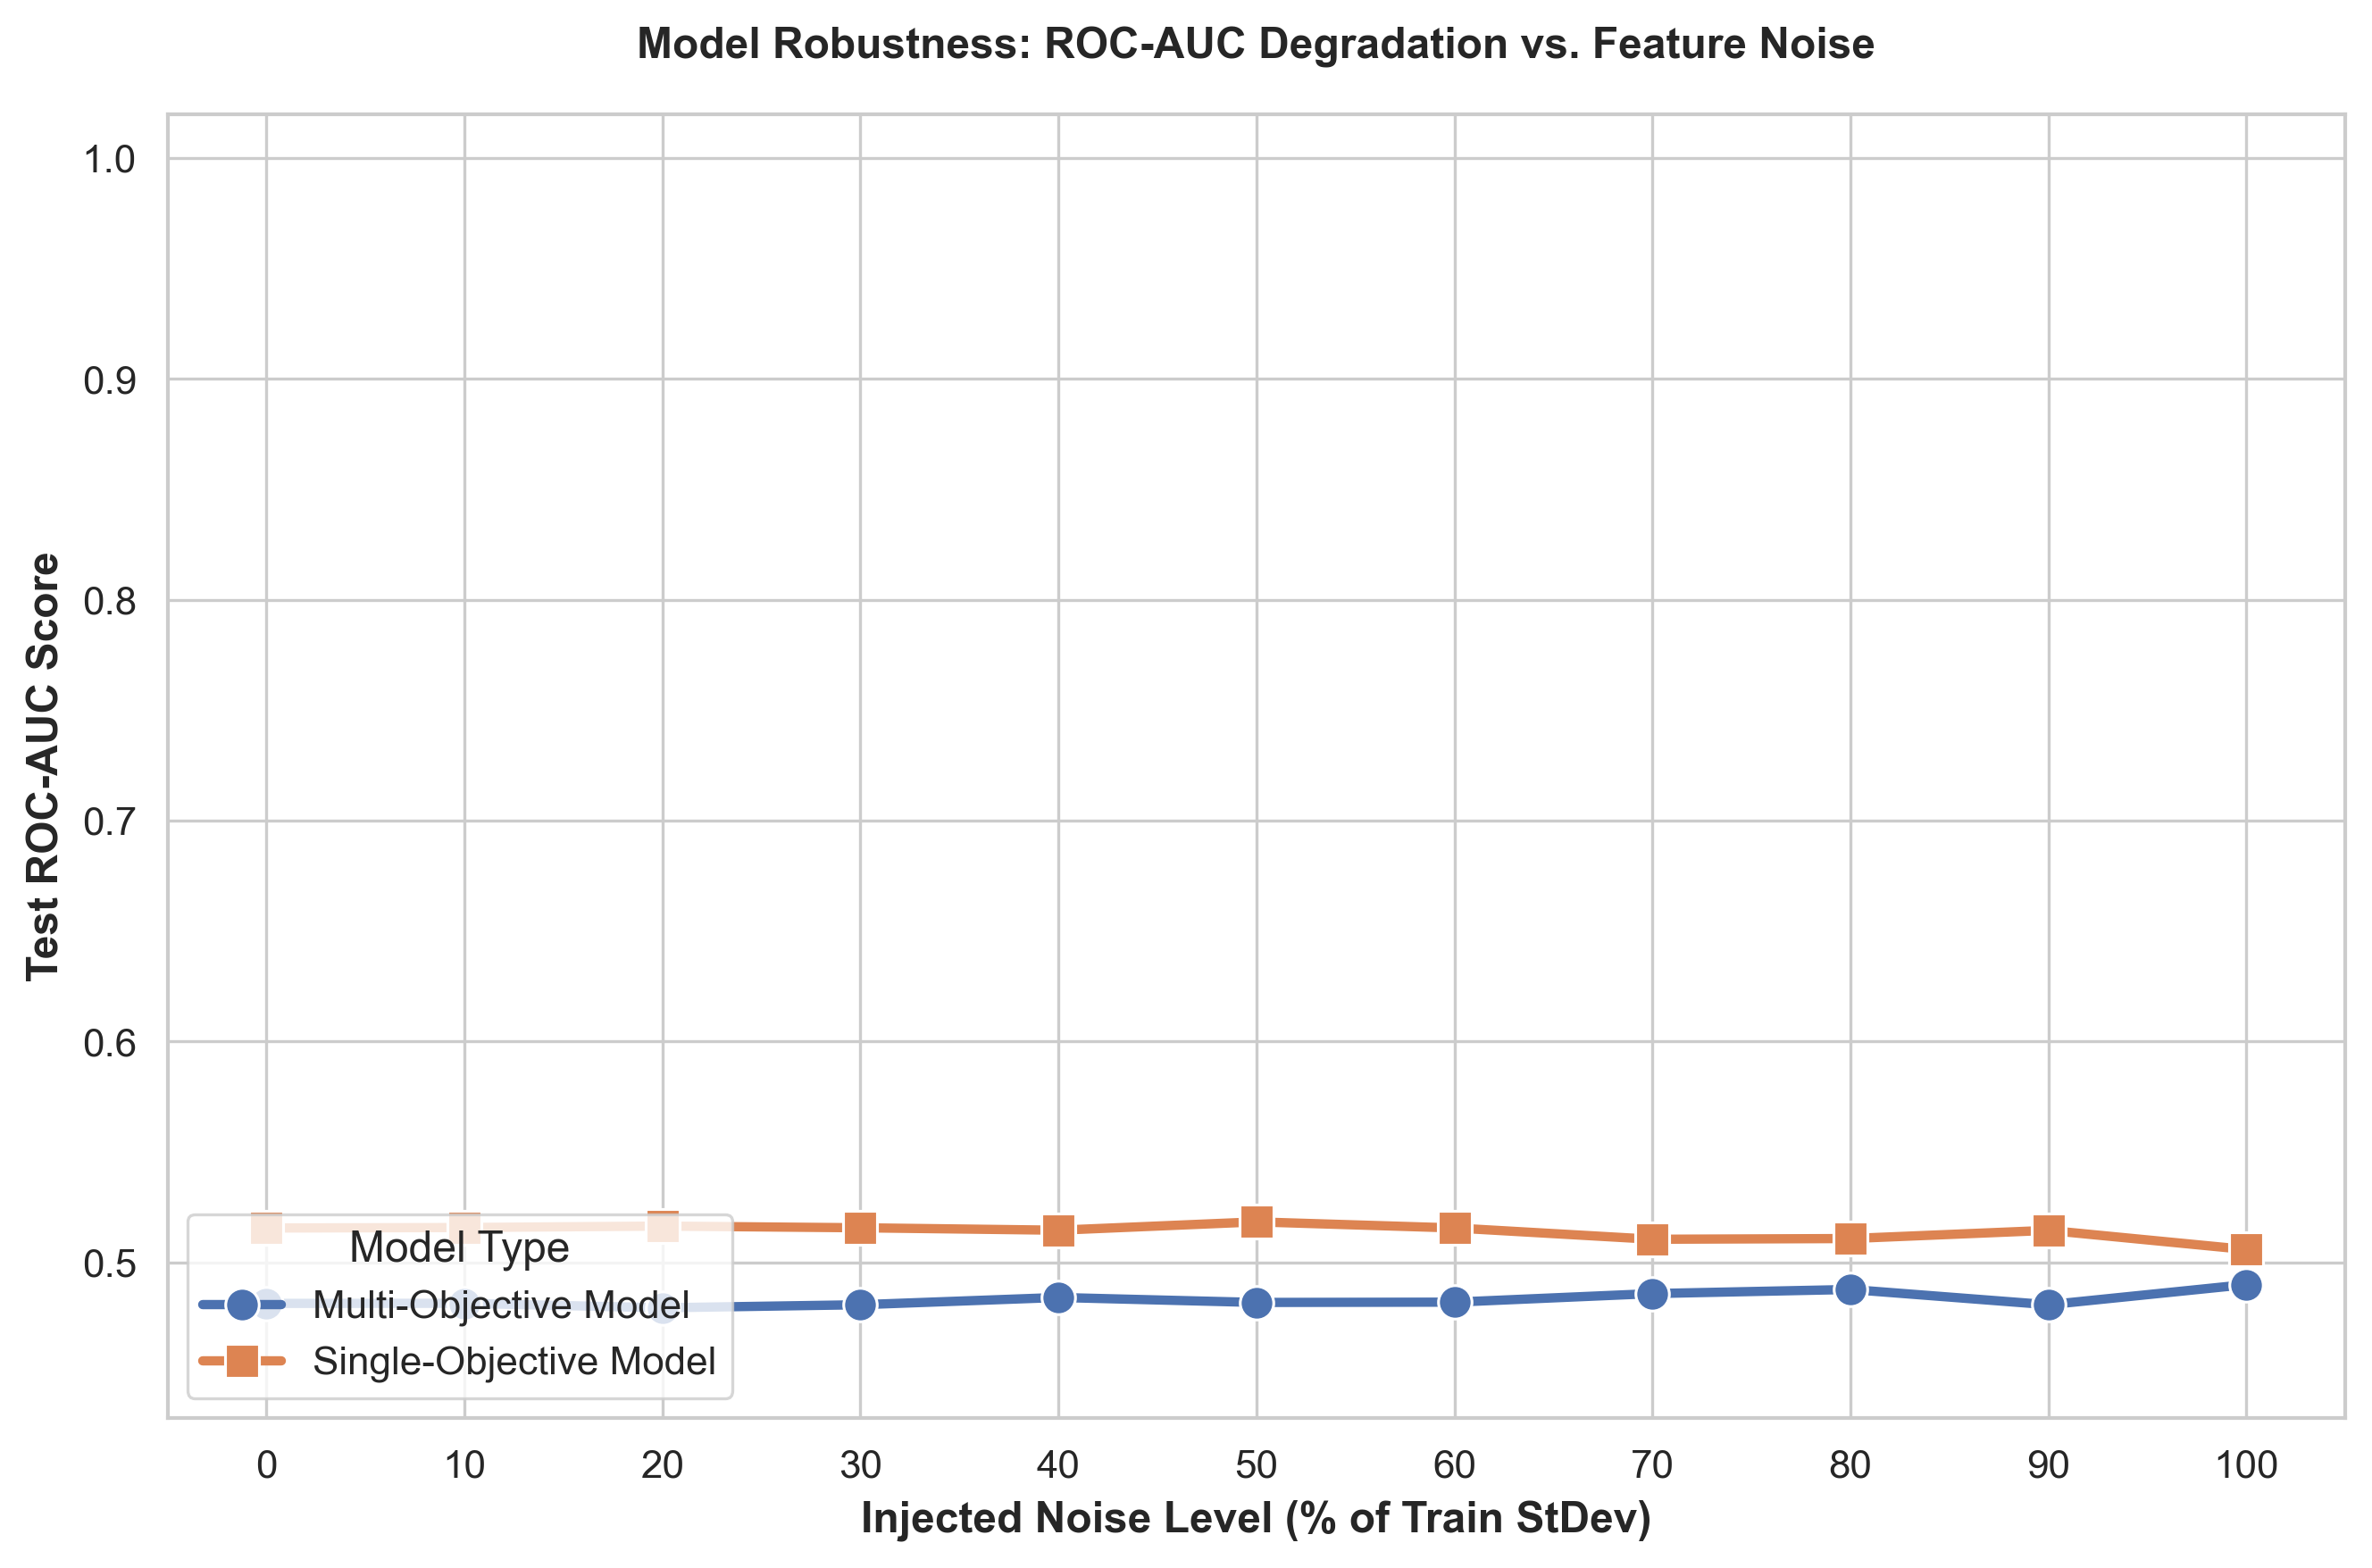

In [35]:
CONTINUOUS_COLS: list[str] = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'total_previous_visits'
]

TARGET_COL: str = "target_readmitted"
TRAIN_CSV_PATH: str = "readmit/readmit_130_hospitals_preprocessed_train_data.csv"
TEST_CSV_PATH: str = "readmit/readmit_130_hospitals_preprocessed_test_data.csv"

df_train: pandas.DataFrame = pandas.read_csv(TRAIN_CSV_PATH)
df_test: pandas.DataFrame = pandas.read_csv(TEST_CSV_PATH)

# Feature and Target separation
X_train: pandas.DataFrame = df_train.drop(columns=[TARGET_COL])
X_test: pandas.DataFrame = df_test.drop(columns=[TARGET_COL])
y_test: pandas.Series = df_test[TARGET_COL]

# Calculate the standard deviation of the training set for noise injection
train_std: pandas.Series = X_train.std()

# Load the models
multi_pkg: dict[str, Any] = load_model_package("multi_objective_model_package.joblib")
single_pkg: dict[str, Any] = load_model_package("single_objective_model_package.joblib")

# Store the results for plotting
results: list[dict[str, Any]] = []

# Noise levels: from 0.0 to 1.0 with 0.1 steps (0%, 10%, ..., 100%)
noise_levels: numpy.ndarray = numpy.arange(0.0, 1.1, 0.1)

print("Evaluation started for different noise levels...")
for noise in noise_levels:
    # Add noise to the test data (based on the training std)
    X_test_noisy: pandas.DataFrame = apply_proportional_noise(X_test, train_std, noise, CONTINUOUS_COLS)

    # Evaluate the Multi-objective model
    auc_multi: float = evaluate_pipeline(multi_pkg, X_test_noisy, y_test)
    results.append({
        "Noise Level (%)": noise * 100,
        "ROC-AUC": auc_multi,
        "Model": "Multi-Objective Model"
    })

    # Evaluate the Single-objective model
    auc_single: float = evaluate_pipeline(single_pkg, X_test_noisy, y_test)
    results.append({
        "Noise Level (%)": noise * 100,
        "ROC-AUC": auc_single,
        "Model": "Single-Objective Model"
    })

    print(f"    - Noise: {noise*100:3.0f}% | Multi AUC: {auc_multi:.4f} | Single AUC: {auc_single:.4f}")

# DataFrame generation from the results
results_df: pandas.DataFrame = pandas.DataFrame(results)

print("Plot generation...")
plt.figure(figsize=(9, 6))

# Line and point plot (lineplot markers)
ax: matplotlib.axes.Axes = sns.lineplot(
    data=results_df,
    x="Noise Level (%)",
    y="ROC-AUC",
    hue="Model",
    style="Model",
    markers=["o", "s"], # Circle and square markers for distinction
    dashes=False,
    linewidth=2.5,
    markersize=9
)

# X axis formatting to have ticks only at the steps
plt.xticks(numpy.arange(0, 110, 10))

# Titles and labels (can be translated to English for publication)
plt.title("Model Robustness: ROC-AUC Degradation vs. Feature Noise", fontweight='bold', pad=15)
plt.xlabel("Injected Noise Level (% of Train StDev)", fontweight='bold')
plt.ylabel("Test ROC-AUC Score", fontweight='bold')

# Y axis limit dynamic and aesthetic setting
plt.ylim(max(0.0, results_df["ROC-AUC"].min() - 0.05), 1.02)

# Legend formatting
plt.legend(title="Model Type", loc='lower left')
plt.tight_layout()

# Save the plot for publication
#plt.savefig("model_robustness_noise_injection.pdf", format="pdf", bbox_inches="tight")
#plt.savefig("model_robustness_noise_injection.png", format="png", bbox_inches="tight")
plt.show()